# Lojistik Regresyon Eğitimi

Bu notebook eğitim ve doğrulama bölümlerini yükleyip sigmoid aktivasyonlu bir lojistik regresyon modeli eğitir; öğrenilen parametreleri ve tanısal görselleri kaydeder.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Özellik Ölçekleme (standardizasyon)
- tanım: Train ortalama/std ile ölçeklenir; val/test aynı istatistikleri kullanır.
- not: std=0 ise 1.0 alınır (bölme hatasını önler).

In [ ]:
# Özellik ölçekleme: Ortalama-standart sapma kullanarak normalize ediyoruz.
# tanım: Her özellik aynı ölçeğe gelir, gradyan inişi daha stabil hale gelir.
DATA_DIR = Path('dataset')
PLOTS_DIR = DATA_DIR / 'gorseller'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train_data.csv'
VAL_PATH = DATA_DIR / 'validation_data.csv'

feature_columns = ['exam_1', 'exam_2']
target_column = 'hired'

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

X_train = train_df[feature_columns].to_numpy(dtype=np.float64)
y_train = train_df[target_column].to_numpy(dtype=np.float64)
X_val = val_df[feature_columns].to_numpy(dtype=np.float64)
y_val = val_df[target_column].to_numpy(dtype=np.float64)

# Eğitim istatistikleriyle özellikleri ölçekle (gradyan inişini kararlı kılar)
feature_means = X_train.mean(axis=0)
feature_stds = X_train.std(axis=0)
feature_stds[feature_stds == 0.0] = 1.0

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

In [ ]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """
    tanım:
        Sigmoid (lojistik) aktivasyon; girişi 0-1 aralığına sıkıştırır.
    args:
        z: np.ndarray — modelin lineer çıktısı (X@w + b).
    """
    clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-clipped))

class LogisticRegressionGD:
    """
    tanım:
        Gradyan iniş (GD) ile ikili lojistik regresyon.
    args:
        learning_rate: Öğrenme oranı.
        epochs: Tekrar sayısı.
    """
    def __init__(self, learning_rate: float = 0.1, epochs: int = 4000):
    
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights: np.ndarray | None = None
        self.bias: float = 0.0

    def fit(self, X: np.ndarray, y: np.ndarray, *, X_val: np.ndarray | None = None, y_val: np.ndarray | None = None) -> dict[str, list[float]]:
        """
        tanım:
            Modeli GD ile eğitir; kayıp ve başarım geçmişini döndürür.
        argümanlar:
            X: Eğitim özellikleri (n_samples, n_features)
            y: Etiketler (0/1)
            X_val, y_val: İsteğe bağlı doğrulama seti.
        döndürür:
            history: {'train_loss', 'train_accuracy', (varsa) 'val_loss', 'val_accuracy'}
        """
        samples, features = X.shape
        self.weights = np.zeros(features, dtype=np.float64)
        self.bias = 0.0

        history: dict[str, list[float]] = {"train_loss": [], "train_accuracy": []}
        if X_val is not None and y_val is not None:
            history["val_loss"] = []
            history["val_accuracy"] = []

        eps = 1e-12  # sayısal güvenlik için küçük sabit (log(0) kaçınma)

        for _ in range(self.epochs):
            linear_output = X @ self.weights + self.bias
            probabilities = sigmoid(linear_output)

            errors = probabilities - y
            gradient_weights = (X.T @ errors) / samples
            gradient_bias = errors.mean()

            # w ve b güncellemesi (gradyan iniş)
            self.weights -= self.learning_rate * gradient_weights
            self.bias -= self.learning_rate * gradient_bias

            predictions = (probabilities >= 0.5).astype(np.int_)  # karar eşiği: 0.5
            train_loss = (-(y * np.log(probabilities + eps)) - ((1.0 - y) * np.log(1.0 - probabilities + eps))).mean()
            train_accuracy = float((predictions == y).mean())

            history["train_loss"].append(float(train_loss))
            history["train_accuracy"].append(train_accuracy)

            if X_val is not None and y_val is not None:
                val_output = X_val @ self.weights + self.bias
                val_probabilities = sigmoid(val_output)
                val_predictions = (val_probabilities >= 0.5).astype(np.int_)
                val_loss = (-(y_val * np.log(val_probabilities + eps)) - ((1.0 - y_val) * np.log(1.0 - val_probabilities + eps))).mean()
                val_accuracy = float((val_predictions == y_val).mean())

                history["val_loss"].append(float(val_loss))
                history["val_accuracy"].append(val_accuracy)

        return history

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        tanım:
            Olasılık çıktısı p(y=1|x).
        argümanlar:
            X: Özellik matrisi.
        döndürür:
            [0,1] aralığında olasılıklar.
        """
        if self.weights is None:
            raise RuntimeError('Model henüz eğitilmedi.')
        return sigmoid(X @ self.weights + self.bias)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        tanım:
            Sınıf etiketi tahmini (0/1).
        argümanlar:
            X: Özellik matrisi.
        not:
            Karar eşiği 0.5 olarak alınır.
        """
        return (self.predict_proba(X) >= 0.5).astype(np.int_)

## Aktivasyon fonksiyonu (sigmoid) tanımı
- tanım: p = 1/(1+e^{-z}) ile olasılık üretir.

## Kayıp fonksiyonu (Binary Cross-Entropy)
- tanım: BCE, doğru sınıf olasılığının log’unu cezalandırır; log(0) hatasına karşı eps eklenir.

## Gradyan güncellemesi
- tanım: w := w - η * \u2207_w; b := b - η * \u2207_b (ortalama hata ile).

## Karar eşiği
- tanım: p ≥ 0.5 ise sınıf=1, aksi halde 0 (ikili karar).

In [ ]:
model = LogisticRegressionGD(learning_rate=0.1, epochs=4000)
history = model.fit(X_train_scaled, y_train, X_val=X_val_scaled, y_val=y_val)

train_accuracy = history['train_accuracy'][-1]
val_accuracy = history['val_accuracy'][-1]
print(f'Eğitim başarımı: {train_accuracy:.4f}')
print(f'Doğrulama başarımı: {val_accuracy:.4f}')

Train accuracy: 0.8833
Validation accuracy: 0.9500


## Eğitim/Doğrulama eğrileri
- tanım: Loss ve accuracy zaman içinde nasıl değişiyor gösterilir.

Saved training curves to /home/internet/Desktop/ml/dataset/gorseller/train_validation_metrics.png


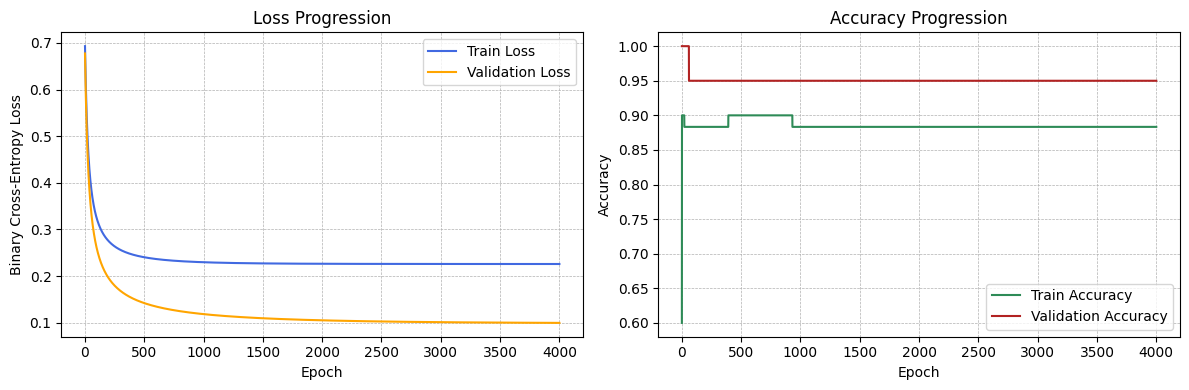

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Eğitim Kaybı', color='royalblue')
axes[0].plot(epochs, history['val_loss'], label='Doğrulama Kaybı', color='orange')
axes[0].set_xlabel('Epok')
axes[0].set_ylabel('İkili Çapraz Entropi Kaybı')
axes[0].set_title('Kayıp Gidişatı')
axes[0].legend()
axes[0].grid(True, linestyle='--', linewidth=0.5)

axes[1].plot(epochs, history['train_accuracy'], label='Eğitim Başarımı', color='seagreen')
axes[1].plot(epochs, history['val_accuracy'], label='Doğrulama Başarımı', color='firebrick')
axes[1].set_xlabel('Epok')
axes[1].set_ylabel('Başarım')
axes[1].set_title('Başarım Gidişatı')
axes[1].legend()
axes[1].grid(True, linestyle='--', linewidth=0.5)

fig.tight_layout()
plot_path = PLOTS_DIR / 'egitim_dogrulama_olcutler.png'
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'Eğitim eğrileri {plot_path.resolve()} dosyasına kaydedildi')

In [6]:
model_path = Path('model_weights.npz')
np.savez(model_path,
         weights=model.weights,
         bias=np.array([model.bias]),
         feature_means=feature_means,
         feature_stds=feature_stds)
print(f'Saved trained model to {model_path.resolve()}')

Saved trained model to /home/internet/Desktop/ml/model_weights.npz


## Model kaydetme
- tanım: Ağırlıklar + ölçekleme istatistikleri .npz içine yazılır; testte yeniden kullanılır.